In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
#functions



def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

def lat_bands_gt(data, datadata, minlat,maxlat, detrend = False):
    #select region
    data = data.sel(lat = slice(maxlat,minlat))
    datadata = datadata.sel(lat = slice(maxlat,minlat))
    #calculate anomaly
    data_weights = build_weights(data, datadata)
    data_glbmean = global_mean(data, datadata, data_weights)
    data_glbanom = anomaly(data_glbmean, data_weights, detrend = detrend)
    return data_glbanom


def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds




In [3]:

fp = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m = decode_time(fp).sel(time = slice('2023-07', '2023-12'))


In [4]:
t2m = t2m.mean('time')

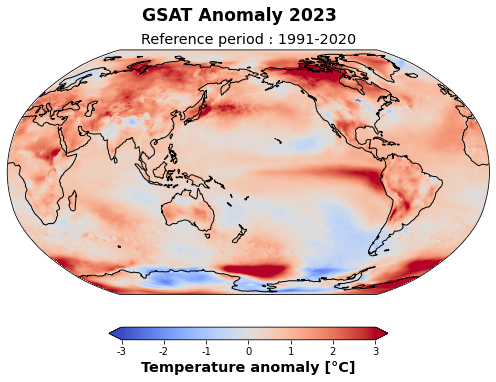

In [5]:
import cartopy.crs as ccrs
import matplotlib.ticker as mticker

"""
masks['open_ocean2'] = xr.where((masks.atlantic>0) & (masks.lat<0), masks.open_ocean*6, masks.open_ocean)

# Define colors for different regions
colors = ['white', 'navy',  'coral', 'red', 'deepskyblue','khaki', 'slateblue']
cmap = (mpl.colors.ListedColormap(colors)
        .with_extremes(under='yellow', over='magenta'))
"""
# Define projection (Robinson projection)
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 6))

# Plot data
im = ax.imshow(t2m.t2m, extent=[0, 360, -90, 90], transform=ccrs.PlateCarree(), cmap='coolwarm', vmin=-3, vmax=3)

# Add coastlines
ax.coastlines()

# Add colorbar
#cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(colors)), orientation='vertical', shrink=0.5)
#cbar.ax.set_yticklabels(['Continents', 'North Atlantic', 'Pacific', 'Indian', 'Arctic', 'Southern', 'South Atlantic'])

cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal', 
                    label = 'Temperature anomaly [°C]', ticks=[-3,-2,-1, 0, 1,2,3], format=mticker.FixedFormatter(['-3','-2','-1', '0', '1','2','3']),
                    extend='both',shrink = 0.5, pad = 0.1)

# Add title
plt.suptitle('GSAT Anomaly 2023', fontweight = 'bold', fontsize = 'xx-large')
plt.title('Reference period : 1991-2020', fontweight = 'normal', fontsize = 'x-large')

plt.show()

In [19]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

na_mask = masks.atlantic.isin([1,2,3])
indian_mask = masks.open_ocean.isin([3])
pacific_mask = masks.open_ocean.isin([2])
atlantic_mask = masks.open_ocean.isin([1])
southern_mask = masks.open_ocean.isin([5])

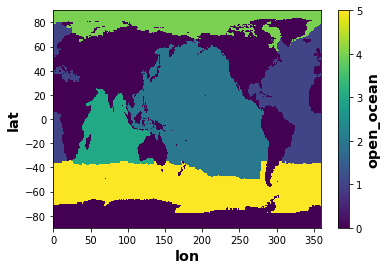

In [20]:
masks.open_ocean.plot()

In [25]:
land = (masks.seamask==0).weighted(w).sum()/(masks.seamask <99).weighted(w).sum()
ocean = (masks.seamask==1).weighted(w).sum()/(masks.seamask <99).weighted(w).sum()

In [26]:
fp = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m = decode_time(fp).sel(time = slice('2023', None))
w = np.cos(np.deg2rad(t2m.lat))


In [27]:
#compute mean
t2m_land_NH = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_NH = t2m_land_NH * (masks.open_ocean.sel(lat = slice(0,90)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land



t2m_land_SH = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_SH = t2m_land_SH * (masks.open_ocean.sel(lat = slice(-90,0)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land


#compute mean
t2m_atl = t2m.where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl = t2m_atl * (masks.open_ocean ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean


#compute mean
t2m_atl_n = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_n = t2m_atl_n * (masks.open_ocean.sel(lat = slice(0,90)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean

#compute mean
t2m_atl_s = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_s = t2m_atl_s * (masks.open_ocean.sel(lat = slice(-90,0)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean



t2m_pac = t2m.where(masks.open_ocean ==2, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_pac = t2m_pac * (masks.open_ocean ==2).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean


t2m_ind = t2m.where(masks.open_ocean ==3, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_ind = t2m_ind * (masks.open_ocean ==3).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean

t2m_arc = t2m.where(masks.open_ocean ==4, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_arc = t2m_arc * (masks.open_ocean ==4).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean

t2m_sou = t2m.where(masks.open_ocean ==5, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_sou = t2m_sou * (masks.open_ocean ==5).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()*ocean

t2m_glb = t2m.weighted(w).mean(['lat', 'lon'])


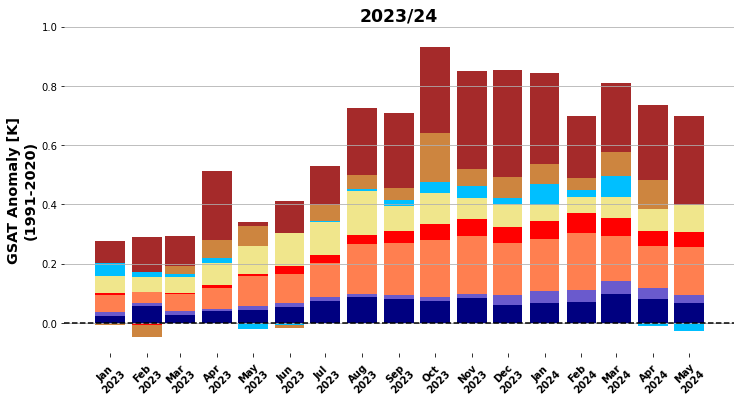

In [28]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(1,1, figsize = (12,6))


bottom_pos = np.zeros(len(t2m_atl['time']))
bottom_neg = np.zeros(len(t2m_atl['time']))

ls = [t2m_atl_n, t2m_atl_s, t2m_pac, t2m_ind, t2m_sou, t2m_arc, t2m_land_SH, t2m_land_NH]
labels = ['North Atlantic', 'South Atlantic', 'Pacific', 'Indian', 'Southern', 'Arctic', 'SH Land', 'NH Land']
colors = ['navy', 'slateblue', 'coral', 'red', 'khaki','deepskyblue','peru', 'brown']

width = np.timedelta64(25, 'D')  # Width in terms of 25 days

for i, r in enumerate(ls):
    values = r['t2m'].values
    bottom = np.where(values >= 0, bottom_pos, bottom_neg)
    ax.bar(r['time'].values, values, width=width.astype('timedelta64[D]').astype('timedelta64[ns]'),
           bottom=bottom, label=labels[i], color = colors[i])
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)
    
    


# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

# Set custom x-axis ticks to show month abbreviations and year
months = r['time'].dt.strftime('%b').values  # Abbreviated month names
years = r['time'].dt.strftime('\n%Y').values  # Years on a new line
ax.set_xticks(r['time'].values)
ax.set_xticklabels([f'{m}{y}' for m, y in zip(months, years)])
ax.set_ylim(-0.1,1.)

# Add legend, labels, and title
#ax.legend()
ax.set_ylabel('GSAT Anomaly [K]\n(1991-2020)')
ax.set_title('2023/24')
plt.xticks(rotation=45, fontweight = 'bold', size = 10)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


In [29]:
fp = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m = decode_time(fp).sel(time = slice('2015', '2016-05'))
w = np.cos(np.deg2rad(t2m.lat))


In [30]:
#compute mean
t2m_land_NH = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_NH = t2m_land_NH * (masks.open_ocean.sel(lat = slice(0,90)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land

t2m_land_SH = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_SH = t2m_land_SH * (masks.open_ocean.sel(lat = slice(-90,0)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land


#compute mean
t2m_atl = t2m.where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl = t2m_atl * (masks.open_ocean ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


#compute mean
t2m_atl_n = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_n = t2m_atl_n * (masks.open_ocean.sel(lat = slice(0,90)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

#compute mean
t2m_atl_s = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_s = t2m_atl_s * (masks.open_ocean.sel(lat = slice(-90,0)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()



t2m_pac = t2m.where(masks.open_ocean ==2, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_pac = t2m_pac * (masks.open_ocean ==2).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


t2m_ind = t2m.where(masks.open_ocean ==3, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_ind = t2m_ind * (masks.open_ocean ==3).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_arc = t2m.where(masks.open_ocean ==4, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_arc = t2m_arc * (masks.open_ocean ==4).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_sou = t2m.where(masks.open_ocean ==5, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_sou = t2m_sou * (masks.open_ocean ==5).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_glb = t2m.weighted(w).mean(['lat', 'lon'])


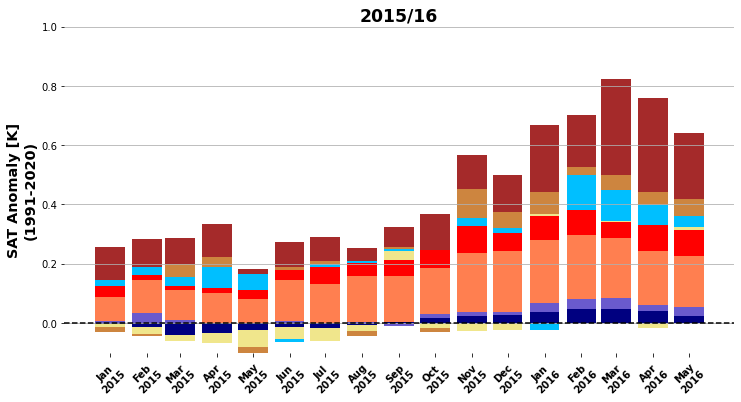

In [31]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(1,1, figsize = (12,6))


bottom_pos = np.zeros(len(t2m_atl['time']))
bottom_neg = np.zeros(len(t2m_atl['time']))

ls = [t2m_atl_n, t2m_atl_s, t2m_pac, t2m_ind, t2m_sou, t2m_arc, t2m_land_SH, t2m_land_NH]
labels = ['North Atlantic', 'South Atlantic', 'Pacific', 'Indian', 'Southern', 'Arctic', 'SH Land', 'NH Land']
colors = ['navy', 'slateblue', 'coral', 'red', 'khaki','deepskyblue','peru', 'brown']

width = np.timedelta64(25, 'D')  # Width in terms of 25 days

for i, r in enumerate(ls):
    values = r['t2m'].values
    bottom = np.where(values >= 0, bottom_pos, bottom_neg)
    ax.bar(r['time'].values, values, width=width.astype('timedelta64[D]').astype('timedelta64[ns]'),
           bottom=bottom, label=labels[i], color = colors[i])
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)
    
    


# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

# Set custom x-axis ticks to show month abbreviations and year
months = r['time'].dt.strftime('%b').values  # Abbreviated month names
years = r['time'].dt.strftime('\n%Y').values  # Years on a new line
ax.set_xticks(r['time'].values)
ax.set_xticklabels([f'{m}{y}' for m, y in zip(months, years)])
ax.set_ylim(-0.1,1.)

# Add legend, labels, and title
#ax.legend()
ax.set_ylabel('SAT Anomaly [K]\n(1991-2020)')
ax.set_title('2015/16')
plt.xticks(rotation=45, fontweight = 'bold', size = 10)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

In [32]:
fp = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m = decode_time(fp).sel(time = slice('1997', '1998-05'))
w = np.cos(np.deg2rad(t2m.lat))


In [33]:
#compute mean
t2m_land_NH = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_NH = t2m_land_NH * (masks.open_ocean.sel(lat = slice(0,90)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land

t2m_land_SH = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_SH = t2m_land_SH * (masks.open_ocean.sel(lat = slice(-90,0)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land


#compute mean
t2m_atl = t2m.where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl = t2m_atl * (masks.open_ocean ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


#compute mean
t2m_atl_n = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_n = t2m_atl_n * (masks.open_ocean.sel(lat = slice(0,90)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

#compute mean
t2m_atl_s = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_s = t2m_atl_s * (masks.open_ocean.sel(lat = slice(-90,0)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()



t2m_pac = t2m.where(masks.open_ocean ==2, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_pac = t2m_pac * (masks.open_ocean ==2).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


t2m_ind = t2m.where(masks.open_ocean ==3, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_ind = t2m_ind * (masks.open_ocean ==3).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_arc = t2m.where(masks.open_ocean ==4, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_arc = t2m_arc * (masks.open_ocean ==4).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_sou = t2m.where(masks.open_ocean ==5, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_sou = t2m_sou * (masks.open_ocean ==5).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_glb = t2m.weighted(w).mean(['lat', 'lon'])


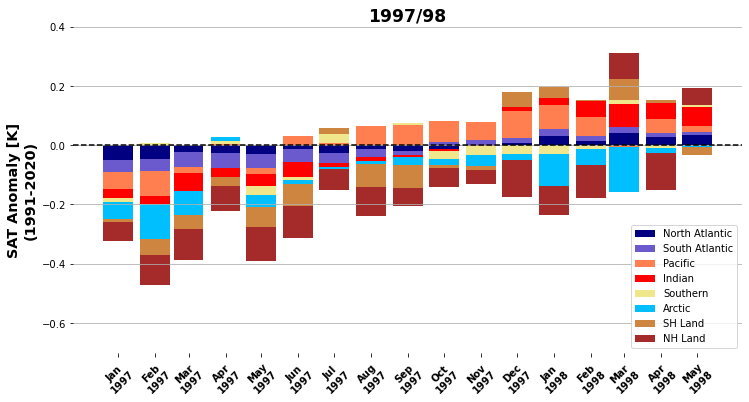

In [34]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(1,1, figsize = (12,6))


bottom_pos = np.zeros(len(t2m_atl['time']))
bottom_neg = np.zeros(len(t2m_atl['time']))

ls = [t2m_atl_n, t2m_atl_s, t2m_pac, t2m_ind, t2m_sou, t2m_arc, t2m_land_SH, t2m_land_NH]
labels = ['North Atlantic', 'South Atlantic', 'Pacific', 'Indian', 'Southern', 'Arctic', 'SH Land', 'NH Land']
colors = ['navy', 'slateblue', 'coral', 'red', 'khaki','deepskyblue','peru', 'brown']

width = np.timedelta64(25, 'D')  # Width in terms of 25 days

for i, r in enumerate(ls):
    values = r['t2m'].values
    bottom = np.where(values >= 0, bottom_pos, bottom_neg)
    ax.bar(r['time'].values, values, width=width.astype('timedelta64[D]').astype('timedelta64[ns]'),
           bottom=bottom, label=labels[i], color = colors[i])
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)
    
    


# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

# Set custom x-axis ticks to show month abbreviations and year
months = r['time'].dt.strftime('%b').values  # Abbreviated month names
years = r['time'].dt.strftime('\n%Y').values  # Years on a new line
ax.set_xticks(r['time'].values)
ax.set_xticklabels([f'{m}{y}' for m, y in zip(months, years)])
ax.set_ylim(-0.7,.4)

# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SAT Anomaly [K]\n(1991-2020)')
ax.set_title('1997/98')
plt.xticks(rotation=45, fontweight = 'bold', size = 10)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

In [20]:
fp = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m = decode_time(fp).sel(time = slice('1982', '1983-05'))
w = np.cos(np.deg2rad(t2m.lat))


In [21]:
#compute mean
t2m_land_NH = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_NH = t2m_land_NH * (masks.open_ocean.sel(lat = slice(0,90)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land

t2m_land_SH = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==0, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_land_SH = t2m_land_SH * (masks.open_ocean.sel(lat = slice(-90,0)) ==0).weighted(w).sum()/(masks.seamask==0).weighted(w).sum()*land


#compute mean
t2m_atl = t2m.where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl = t2m_atl * (masks.open_ocean ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


#compute mean
t2m_atl_n = t2m.sel(lat = slice(90,0)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_n = t2m_atl_n * (masks.open_ocean.sel(lat = slice(0,90)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

#compute mean
t2m_atl_s = t2m.sel(lat = slice(0,-90)).where(masks.open_ocean ==1, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_atl_s = t2m_atl_s * (masks.open_ocean.sel(lat = slice(-90,0)) ==1).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()



t2m_pac = t2m.where(masks.open_ocean ==2, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_pac = t2m_pac * (masks.open_ocean ==2).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()


t2m_ind = t2m.where(masks.open_ocean ==3, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_ind = t2m_ind * (masks.open_ocean ==3).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_arc = t2m.where(masks.open_ocean ==4, drop = True).weighted(w).mean(['lat', 'lon'])\
#weight contribution
t2m_arc = t2m_arc * (masks.open_ocean ==4).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_sou = t2m.where(masks.open_ocean ==5, drop = True).weighted(w).mean(['lat', 'lon'])
#weight contribution
t2m_sou = t2m_sou * (masks.open_ocean ==5).weighted(w).sum()/(masks.seamask==1).weighted(w).sum()

t2m_glb = t2m.weighted(w).mean(['lat', 'lon'])


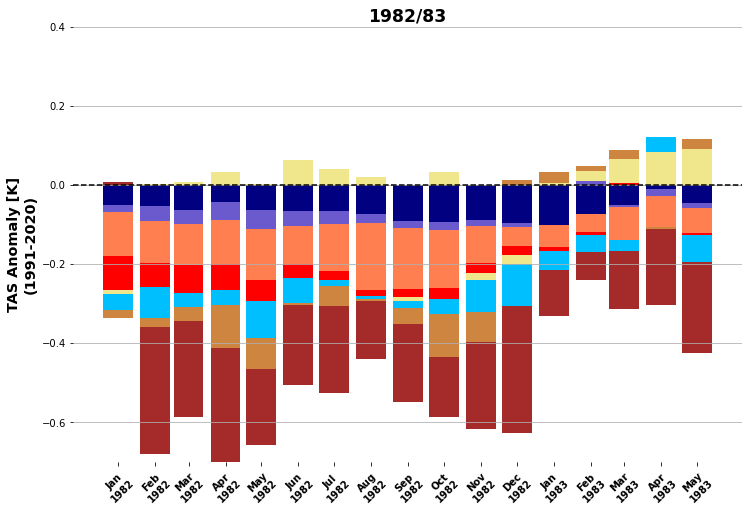

In [22]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(1,1, figsize = (12,8))


bottom_pos = np.zeros(len(t2m_atl['time']))
bottom_neg = np.zeros(len(t2m_atl['time']))

ls = [t2m_atl_n, t2m_atl_s, t2m_pac, t2m_ind, t2m_sou, t2m_arc, t2m_land_SH, t2m_land_NH]
labels = ['North Atlantic', 'South Atlantic', 'Pacific', 'Indian', 'Southern', 'Arctic', 'SH Land', 'NH Land']
colors = ['navy', 'slateblue', 'coral', 'red', 'khaki','deepskyblue','peru', 'brown']

width = np.timedelta64(25, 'D')  # Width in terms of 25 days

for i, r in enumerate(ls):
    values = r['t2m'].values
    bottom = np.where(values >= 0, bottom_pos, bottom_neg)
    ax.bar(r['time'].values, values, width=width.astype('timedelta64[D]').astype('timedelta64[ns]'),
           bottom=bottom, label=labels[i], color = colors[i])
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)
    
    


# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

# Set custom x-axis ticks to show month abbreviations and year
months = r['time'].dt.strftime('%b').values  # Abbreviated month names
years = r['time'].dt.strftime('\n%Y').values  # Years on a new line
ax.set_xticks(r['time'].values)
ax.set_xticklabels([f'{m}{y}' for m, y in zip(months, years)])
ax.set_ylim(-0.7,.4)

# Add legend, labels, and title
#ax.legend()
ax.set_ylabel('TAS Anomaly [K]\n(1991-2020)')
ax.set_title('1982/83')
plt.xticks(rotation=45, fontweight = 'bold', size = 10)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

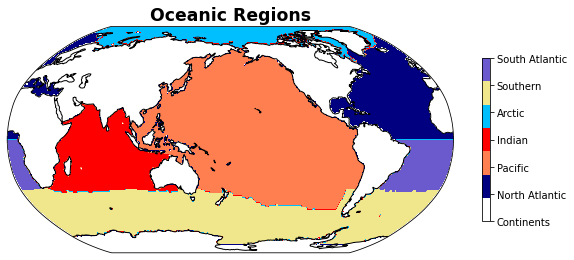

In [250]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl

masks['open_ocean2'] = xr.where((masks.atlantic>0) & (masks.lat<0), masks.open_ocean*6, masks.open_ocean)

# Define colors for different regions
colors = ['white', 'navy',  'coral', 'red', 'deepskyblue','khaki', 'slateblue']
cmap = (mpl.colors.ListedColormap(colors)
        .with_extremes(under='yellow', over='magenta'))

# Define projection (Robinson projection)
projection = ccrs.Robinson(central_longitude=180)

# Create figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 6))

# Plot data
im = ax.imshow(masks.open_ocean2, extent=[0, 360, 90, -90], transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=len(colors)-1)

# Add coastlines
ax.coastlines()

# Add colorbar
cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(colors)), orientation='vertical', shrink=0.5)
cbar.ax.set_yticklabels(['Continents', 'North Atlantic', 'Pacific', 'Indian', 'Arctic', 'Southern', 'South Atlantic'])

# Add title
plt.title('Oceanic Regions')

plt.show()


# Make one Compund event


# Nino Index


In [9]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)

In [ ]:
nino34 = sst.sel(lon=slice(360-170.,360-120.), lat=slice(5,-5))
w = np.cos(np.deg2rad(nino34.lat))
nino34 = nino34.weighted(w).mean()
nino34 = nino34.groupby('time.month')-nino34.groupby('time.month').mean()

In [ ]:
nino34.rolling(time = 3, center = True, min_periods = 1).mean()

# Make plots in one graph



In [23]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Function to create each individual plot
def create_plot(t2m, masks, ax, title):
    w = np.cos(np.deg2rad(t2m.lat))

    t2m_land_NH = t2m.sel(lat=slice(90, 0)).where(masks.open_ocean == 0, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_land_NH = t2m_land_NH * (masks.open_ocean.sel(lat=slice(0, 90)) == 0).weighted(w).sum() / (masks.seamask == 0).weighted(w).sum() * land

    t2m_land_SH = t2m.sel(lat=slice(0, -90)).where(masks.open_ocean == 0, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_land_SH = t2m_land_SH * (masks.open_ocean.sel(lat=slice(-90, 0)) == 0).weighted(w).sum() / (masks.seamask == 0).weighted(w).sum() * land

    t2m_atl = t2m.where(masks.open_ocean == 1, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_atl = t2m_atl * (masks.open_ocean == 1).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_atl_n = t2m.sel(lat=slice(90, 0)).where(masks.open_ocean == 1, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_atl_n = t2m_atl_n * (masks.open_ocean.sel(lat=slice(0, 90)) == 1).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_atl_s = t2m.sel(lat=slice(0, -90)).where(masks.open_ocean == 1, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_atl_s = t2m_atl_s * (masks.open_ocean.sel(lat=slice(-90, 0)) == 1).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_pac = t2m.where(masks.open_ocean == 2, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_pac = t2m_pac * (masks.open_ocean == 2).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_ind = t2m.where(masks.open_ocean == 3, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_ind = t2m_ind * (masks.open_ocean == 3).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_arc = t2m.where(masks.open_ocean == 4, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_arc = t2m_arc * (masks.open_ocean == 4).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_sou = t2m.where(masks.open_ocean == 5, drop=True).weighted(w).mean(['lat', 'lon'])
    t2m_sou = t2m_sou * (masks.open_ocean == 5).weighted(w).sum() / (masks.seamask == 1).weighted(w).sum() * ocean

    t2m_glb = t2m.weighted(w).mean(['lat', 'lon'])

    bottom_pos = np.zeros(len(t2m_atl['time']))
    bottom_neg = np.zeros(len(t2m_atl['time']))

    ls = [t2m_atl_n, t2m_atl_s, t2m_pac, t2m_ind, t2m_sou, t2m_arc, t2m_land_SH, t2m_land_NH]
    labels = ['North Atlantic', 'South Atlantic', 'Pacific', 'Indian', 'Southern', 'Arctic', 'SH Land', 'NH Land']
    colors = ['navy', 'slateblue', 'coral', 'red', 'khaki', 'deepskyblue', 'peru', 'brown']

    width = np.timedelta64(25, 'D')  # Width in terms of 25 days

    for i, r in enumerate(ls):
        values = r['t2m'].values
        bottom = np.where(values >= 0, bottom_pos, bottom_neg)
        ax.bar(r['time'].values, values, width=width.astype('timedelta64[D]').astype('timedelta64[ns]'),
               bottom=bottom, label=labels[i], color=colors[i])
        bottom_pos += np.where(values >= 0, values, 0)
        bottom_neg += np.where(values < 0, values, 0)

    ax.axhline(0, color='black', linestyle='--')

    months = r['time'].dt.strftime('%b').values
    years = r['time'].dt.strftime('\n%Y').values
    ax.set_xticks(r['time'].values)
    ax.set_xticklabels([f'{m}{y}' for m, y in zip(months, years)])
    ax.set_ylim(-0.1, 1.)

    ax.legend()
    ax.set_ylabel('Anomaly [K]\n(1991-2020)')
    ax.set_title(title)
    plt.xticks(rotation=45, fontweight='bold', size=10)

    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)



In [ ]:
# Load data for different time slices and masks

fig, axs = plt.subplots(2, 2, figsize=(24, 16))

# First time slice
fp1 = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m1 = decode_time(fp1).sel(time=slice('2023', None))
create_plot(t2m1, masks, axs[0, 0], 'TAS over Ocean (2023/24)')

In [ ]:
# Second time slice
fp2 = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m2 = decode_time(fp2).sel(time=slice('2015', '2016-05'))
create_plot(t2m2, masks, axs[0, 1], 'TAS Oceanic Contribution (2015 - 2016-05)')

# Third time slice (add your specific time range)
fp3 = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m3 = decode_time(fp3).sel(time=slice('your_start_date', 'your_end_date'))
create_plot(t2m3, masks, axs[1, 0], 'TAS Oceanic Contribution (your_start_date - your_end_date)')

# Fourth time slice (add your specific time range)
fp4 = '/data/jmex/ERA5/monthly/era5_t2m_1991_2020_anom.nc'
t2m4 = decode_time(fp4).sel(time=slice('your_start_date', 'your_end_date'))
create_plot(t2m4, masks, axs[1, 1], 'TAS Oceanic Contribution (your_start_date - your_end_date)')

plt.tight_layout()
plt.show()